In [ ]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.duration.hazard_regression import PHReg

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Análisis de COMPAS

A continuación se presentan los cálculos realizados por ProPublica para el análisis de las puntuaciones de riesgo de reincidencia de COMPAS. Para comprender mejor lo siguiente, puede ser útil abrir [la metodología](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) en otra pestaña.

## Carga de datos

Seleccionamos los campos correspondientes a la gravedad del cargo, el número de antecedentes penales, datos demográficos, edad, sexo, puntuaciones de COMPAS y si cada persona fue acusada de un delito en los últimos dos años.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
raw_data = pd.read_csv("data\\raw\\compas-scores-two-years.csv")
print(len(raw_data))

7214


Sin embargo, no todas las filas son utilizables para la primera ronda de análisis.

Existen varias razones para eliminar filas debido a la falta de datos:
* Si la fecha de la acusación por el delito puntuado por Compas de un acusado no se encuentra dentro de los 30 días posteriores a su arresto, asumimos que, debido a problemas de calidad de los datos, no contamos con el delito correcto.

* Codificamos el indicador de reincidencia —`is_recid`— con el valor -1 si no pudimos encontrar ningún caso en Compas.

* De manera similar, se eliminan las infracciones de tránsito comunes —aquellas con un `c_charge_degree` de 'O'— que no conllevan pena de cárcel (solo dos de ellas).

* Filtramos los datos subyacentes del condado de Broward para incluir solo las filas que representan a personas que habían reincidido en dos años o que habían estado al menos dos años fuera de un centro penitenciario.

In [ ]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out",
]
df = raw_data.loc[:, cols].copy()

# Filter the data according to the criteria specified in the original ProPublica analysis
mask = (
    (df["days_b_screening_arrest"] <= 30)
    & (df["days_b_screening_arrest"] >= -30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
)
df = df.loc[mask].copy()
print(len(df))

6172


Las puntuaciones más altas en la escala COMPAS se correlacionan ligeramente con una estancia hospitalaria más prolongada.

In [8]:
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
print(df["length_of_stay"].corr(df["decile_score"]))

0.20747808478031818


Tras aplicar el filtrado, obtenemos el siguiente desglose demográfico:

In [9]:
print(df['age_cat'].value_counts(dropna=False).sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [10]:
print(df['race'].value_counts(dropna=False).sort_index())

race
African-American    3175
Asian                 31
Caucasian           2103
Hispanic             509
Native American       11
Other                343
Name: count, dtype: int64


In [11]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [12]:
print(df['score_text'].value_counts(dropna=False).sort_index())

score_text
High      1144
Low       3421
Medium    1607
Name: count, dtype: int64


In [13]:
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [14]:
print(df['sex'].value_counts(dropna=False).sort_index())

sex
Female    1175
Male      4997
Name: count, dtype: int64


In [15]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [16]:
print(int((df['two_year_recid'] == 1).sum()))

2809


In [17]:
print(((df['two_year_recid'] == 1).mean()) * 100)

45.51198963058976


Los jueces suelen recibir dos conjuntos de puntuaciones del sistema Compas: uno que clasifica a las personas en riesgo alto, medio y bajo, y una puntuación decil correspondiente. Existe una clara tendencia descendente en las puntuaciones deciles a medida que aumentan las puntuaciones de los acusados ​​blancos.

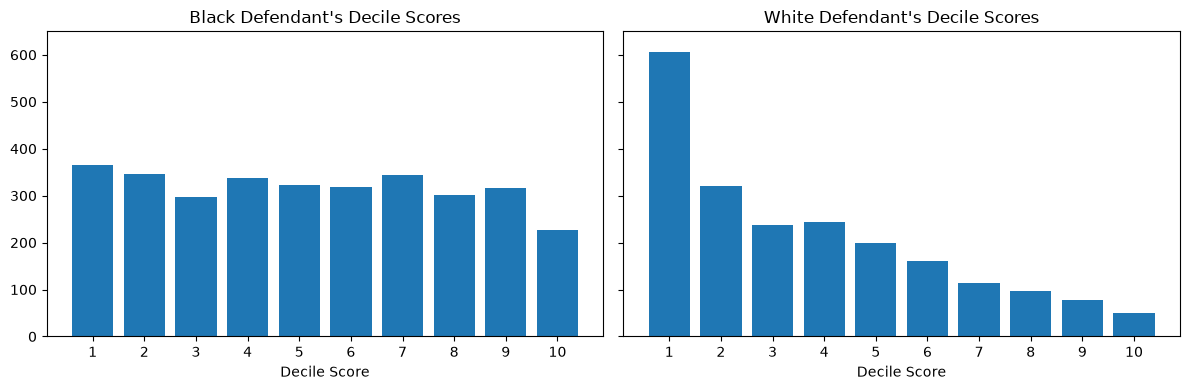

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black = df.loc[df["race"] == "African-American", "decile_score"].value_counts().sort_index()
white = df.loc[df["race"] == "Caucasian", "decile_score"].value_counts().sort_index()

axes[0].bar(black.index.astype(str), black.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

axes[1].bar(white.index.astype(str), white.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [19]:
print(pd.crosstab(df['decile_score'], df['race']))

race          African-American  Asian  Caucasian  Hispanic  Native American  Other
decile_score                                                                      
1                          365     15        605       159                0    142
2                          346      4        321        89                2     60
3                          298      5        238        73                1     32
4                          337      0        243        47                0     39
5                          323      1        200        39                0     19
6                          318      2        160        27                2     20
7                          343      1        113        28                2      9
8                          301      2         96        14                0      7
9                          317      0         77        17                2      7
10                         227      1         50        16                2      8


## Sesgo racial en Compas

Tras filtrar las filas problemáticas, nuestra primera pregunta es si existe una diferencia significativa en las puntuaciones de Compas entre las distintas razas. Para ello, necesitamos convertir algunas variables en factores y realizar una regresión logística, comparando las puntuaciones bajas con las altas.

In [20]:
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = (df["score_text"] != "Low").astype(int)

model = smf.glm(
    "score_factor ~ C(gender_factor, Treatment(reference='Male'))"
    " + C(age_factor, Treatment(reference='25 - 45'))"
    " + C(race_factor, Treatment(reference='Caucasian'))"
    " + priors_count + C(crime_factor) + two_year_recid",
    data=df,
    family=sm.families.Binomial(),
).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Mon, 22 Jun 2026   Deviance:                       6168.4
Time:                        02:13:39   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

Los acusados ​​negros tienen un 45% más de probabilidades que los acusados ​​blancos de recibir una puntuación más alta, teniendo en cuenta la gravedad de su delito, los antecedentes penales y la conducta delictiva futura.

In [21]:
control = math.exp(-1.52554) / (1 + math.exp(-1.52554))
print(math.exp(0.47721) / (1 - control + (control * math.exp(0.47721))))

1.4528408658138932


Las mujeres tienen un 19,4% más de probabilidades que los hombres de obtener una puntuación más alta.

In [ ]:
print(math.exp(0.22127) / (1 - control + (control * math.exp(0.22127))))

Lo más sorprendente es que las personas menores de 25 años tienen 2,5 veces más probabilidades de obtener una puntuación más alta que los acusados ​​de mediana edad.

In [ ]:
print(math.exp(1.30839) / (1 - control + (control * math.exp(1.30839))))

### Riesgo de reincidencia violenta

Compas también ofrece una puntuación que busca medir el riesgo de reincidencia violenta de una persona, la cual tiene una precisión general similar a la puntuación de reincidencia. Como antes, podemos usar una regresión logística para detectar sesgos raciales.

In [ ]:
violent_raw = pd.read_csv("./compas-scores-two-years-violent.csv")
print(len(violent_raw))

In [ ]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out",
]
df = raw_data.loc[:, cols].copy()

mask = (
    (df["days_b_screening_arrest"] <= 30)
    & (df["days_b_screening_arrest"] >= -30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
)
df = df.loc[mask].copy()
print(len(df))

In [ ]:
print(df['age_cat'].value_counts(dropna=False).sort_index())

In [ ]:
print(df['race'].value_counts(dropna=False).sort_index())

In [ ]:
print(df['v_score_text'].value_counts(dropna=False).sort_index())

In [ ]:
print(((df['two_year_recid'] == 1).mean()) * 100)

In [ ]:
print(int((df['two_year_recid'] == 1).sum()))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black = df.loc[df["race"] == "African-American", "v_decile_score"].value_counts().sort_index()
white = df.loc[df["race"] == "Caucasian", "v_decile_score"].value_counts().sort_index()

axes[0].bar(black.index.astype(str), black.values)
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Violent Decile Score")
axes[0].set_ylim(0, 700)

axes[1].bar(white.index.astype(str), white.values)
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Violent Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

In [ ]:
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = (df["score_text"] != "Low").astype(int)

model = smf.glm(
    "score_factor ~ C(gender_factor, Treatment(reference='Male'))"
    " + C(age_factor, Treatment(reference='25 - 45'))"
    " + C(race_factor, Treatment(reference='Caucasian'))"
    " + priors_count + C(crime_factor) + two_year_recid",
    data=df,
    family=sm.families.Binomial(),
).fit()
print(model.summary())

La puntuación de violencia sobreestima la reincidencia en los acusados ​​negros en un 77,3% en comparación con los acusados ​​blancos.

In [ ]:
control = math.exp(-2.24274) / (1 + math.exp(-2.24274))
print(math.exp(0.65893) / (1 - control + (control * math.exp(0.65893))))

Los acusados ​​menores de 25 años tienen 7,4 veces más probabilidades de obtener una puntuación más alta que los acusados ​​de mediana edad.

In [ ]:
print(math.exp(3.14591) / (1 - control + (control * math.exp(3.14591))))

## Precisión predictiva de COMPAS

Para comprobar si las puntuaciones de COMPAS determinan con precisión si un delincuente presenta un riesgo bajo, medio o alto, utilizamos un modelo de riesgos proporcionales de Cox. Northpointe, la empresa que creó COMPAS y lo comercializa para las fuerzas del orden, también utilizó un modelo de Cox en su estudio de validación (http://cjb.sagepub.com/content/36/1/21.abstract).

Utilizamos el modelo de conteo y excluimos a las personas que se encontraban encarceladas. Debido a errores en los datos subyacentes de las cárceles, fue necesario filtrar 32 filas con una fecha de finalización posterior a la fecha de inicio. Dado que los datos contienen un total de 13 334 filas, esta pequeña cantidad de errores no afectará a los resultados.


In [ ]:
data = pd.read_csv("./cox-parsed.csv")
data = data.loc[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

data["race_factor"] = pd.Categorical(
    data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)
data["score_factor"] = pd.Categorical(data["score_text"], ordered=False)
data["score_factor"] = data["score_factor"].cat.reorder_categories(
    sorted(data["score_factor"].dropna().unique().tolist())
)

grp = data.loc[~data["id"].duplicated()].copy()
print(len(grp))

In [ ]:
print(grp['score_factor'].value_counts(dropna=False).sort_index())

In [ ]:
print(grp['race_factor'].value_counts(dropna=False).sort_index())

In [ ]:
cox_model = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=data,
).fit(disp=0)
print(cox_model.summary())

Las personas clasificadas en la categoría de alto riesgo tienen 3,5 veces más probabilidades de reincidir, y la concordancia del sistema COMPAS es del 63,6 %. Esto es inferior a la precisión del 68 % citada en el estudio de Northpoint.

In [ ]:
decile_model = PHReg.from_formula(
    "end ~ decile_score",
    status="event",
    entry="start",
    data=data,
).fit(disp=0)
print(decile_model.summary())

Las puntuaciones de los deciles de COMPAS son un poco más precisas: 66%.

Podemos probar si el algoritmo se comporta de manera diferente entre razas al incluir un término de interacción racial en el modelo de Cox.

In [ ]:
interaction_model = PHReg.from_formula(
    "end ~ C(race_factor, Treatment(reference='Caucasian')) * C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=data,
).fit(disp=0)
print(interaction_model.summary())

El término de interacción muestra una disparidad similar a la de la regresión logística anterior.

Los acusados ​​blancos de alto riesgo tienen 3,61 veces más probabilidades que los acusados ​​blancos de bajo riesgo, mientras que los acusados ​​negros de alto riesgo tienen 2,99 veces más probabilidades que los de bajo riesgo.

In [ ]:
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

In [ ]:
def plot_cox_survival(result, title):
    times, cumhaz, surv = result.baseline_cumulative_hazard[0]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.step(times, surv, where="post")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    plt.tight_layout()
    plt.show()
    return fig, ax

plot_cox_survival(cox_model, "Overall")

Según los gráficos de Kaplan-Meier específicos para cada raza, los acusados ​​negros reinciden con mayor frecuencia.


In [ ]:
white = data.loc[data["race"] == "Caucasian"].copy()
black = data.loc[data["race"] == "African-American"].copy()

white_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=white,
).fit(disp=0)

black_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=black,
).fit(disp=0)

plot_cox_survival(white_fit, "White defendants")
plot_cox_survival(black_fit, "Black defendants")

In [ ]:
# The original notebook summarized the curve at 730 days here.

In [ ]:
# The original notebook summarized the Black curve at 730 days here.

In [ ]:
# The original notebook summarized the White curve at 730 days here.

Race specific models have similar concordance values.

In [ ]:
print(PHReg.from_formula('end ~ C(score_factor, Treatment(reference="Low"))', status='event', entry='start', data=white).fit(disp=0).summary())

In [ ]:
print(PHReg.from_formula('end ~ C(score_factor, Treatment(reference="Low"))', status='event', entry='start', data=black).fit(disp=0).summary())

Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [ ]:
violent_data = pd.read_csv("./cox-violent-parsed.csv")
violent_data = violent_data.loc[(violent_data["score_text"] != "N/A") & (violent_data["end"] > violent_data["start"])].copy()

violent_data["race_factor"] = pd.Categorical(
    violent_data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
)
violent_data["score_factor"] = pd.Categorical(violent_data["score_text"], ordered=False)
violent_data["score_factor"] = violent_data["score_factor"].cat.reorder_categories(
    sorted(violent_data["score_factor"].dropna().unique().tolist())
)

En este caso, no hay un coeficiente significativo en los afroamericanos con puntuaciones altas.


In [ ]:
violent_interaction_model = PHReg.from_formula(
    "end ~ C(race_factor, Treatment(reference='Caucasian')) * C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=violent_data,
).fit(disp=0)
print(violent_interaction_model.summary())

In [ ]:
print(PHReg.from_formula('end ~ C(score_factor, Treatment(reference="Low"))', status='event', entry='start', data=violent_data.loc[violent_data['race'] == 'African-American']).fit(disp=0).summary())

In [ ]:
print(PHReg.from_formula('end ~ C(score_factor, Treatment(reference="Low"))', status='event', entry='start', data=violent_data.loc[violent_data['race'] == 'Caucasian']).fit(disp=0).summary())

In [ ]:
white = violent_data.loc[violent_data["race"] == "Caucasian"].copy()
black = violent_data.loc[violent_data["race"] == "African-American"].copy()

white_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=white,
).fit(disp=0)

black_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=black,
).fit(disp=0)

plot_cox_survival(white_fit, "White defendants")
plot_cox_survival(black_fit, "Black defendants")

## Direcciones del sesgo racial

El análisis anterior muestra que el algoritmo Compas sobrepredice la futura reincidencia del acusado afroamericano, pero aún no hemos explorado la dirección del sesgo. Podemos descubrir sutiles diferencias en la sobrepredicción y la subpredicción comparando las puntuaciones de Compas entre líneas raciales.

In [ ]:
from truth_tables import PeekyReader, Person, table, is_race, count, vtable, hightable, vhightable
from csv import DictReader

people = []
with open("./cox-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                people.append(p)
    except StopIteration:
        pass

pop = list(filter(lambda i: ((i.recidivist == True and i.lifetime <= 730) or
                              i.lifetime > 730), list(filter(lambda x: x.score_valid, people))))
recid = list(filter(lambda i: i.recidivist == True and i.lifetime <= 730, pop))
rset = set(recid)
surv = [i for i in pop if i not in rset]

In [ ]:
print("All defendants")
table(list(recid), list(surv))

In [ ]:
print("Total pop: %i" % (2681 + 1282 + 1216 + 2035))

In [ ]:
import statistics
print("Average followup time %.2f (sd %.2f)" % (statistics.mean(map(lambda i: i.lifetime, pop)),
                                                statistics.stdev(map(lambda i: i.lifetime, pop))))
print("Median followup time %i" % (statistics.median(map(lambda i: i.lifetime, pop))))

En general, la tasa de falsos positivos es del 32,35%.


In [ ]:
print("Black defendants")
is_afam = is_race("African-American")
table(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

Esa cifra es más alta para los afroamericanos, con un 44,85%.


In [ ]:
print("White defendants")
is_white = is_race("Caucasian")
table(list(filter(is_white, recid)), list(filter(is_white, surv)))

Y menor para los blancos, en el 23,45%.

In [ ]:
44.85 / 23.45

Esto significa que, según el sistema COMPAS, los acusados ​​negros tienen un 91% más de probabilidades de obtener una puntuación más alta y de no cometer más delitos que los acusados ​​blancos después de dos años.

Las puntuaciones de COMPAS clasifican erróneamente a los reincidentes blancos como de bajo riesgo un 70,4 % más a menudo que a los reincidentes negros.

In [ ]:
47.72 / 27.99

In [ ]:
hightable(list(filter(is_white, recid)), list(filter(is_white, surv)))

In [ ]:
hightable(list(filter(is_afam, recid)), list(filter(is_afam, surv)))

## Riesgo de reincidencia violenta

Compas también ofrece una puntuación que tiene como objetivo medir el riesgo de reincidencia violenta de una persona, que tiene una precisión general similar a la puntuación de reincidencia.

In [ ]:
vpeople = []
with open("./cox-violent-parsed.csv") as f:
    reader = PeekyReader(DictReader(f))
    try:
        while True:
            p = Person(reader)
            if p.valid:
                vpeople.append(p)
    except StopIteration:
        pass

vpop = list(filter(lambda i: ((i.violent_recidivist == True and i.lifetime <= 730) or
                              i.lifetime > 730), list(filter(lambda x: x.vscore_valid, vpeople))))
vrecid = list(filter(lambda i: i.violent_recidivist == True and i.lifetime <= 730, vpeople))
vrset = set(vrecid)
vsurv = [i for i in vpop if i not in vrset]

In [ ]:
print("All defendants")
vtable(list(vrecid), list(vsurv))

Incluso más para los acusados ​​negros.

In [ ]:
print("Black defendants")
is_afam = is_race("African-American")
vtable(list(filter(is_afam, vrecid)), list(filter(is_afam, vsurv)))

In [ ]:
print("White defendants")
is_white = is_race("Caucasian")
vtable(list(filter(is_white, vrecid)), list(filter(is_white, vsurv)))

Los acusados ​​negros tienen el doble de probabilidades de dar falsos positivos en una puntuación de violencia elevada que los acusados ​​blancos.


In [ ]:
38.14 / 18.46

Los acusados ​​blancos tienen un 63% más de probabilidades de obtener una puntuación más baja y cometer otro delito que los acusados ​​negros.

In [ ]:
62.62 / 38.37

## Diferencias de género en las puntuaciones de Compas

En cuanto a las tasas de reincidencia subyacentes, podemos analizar las estimaciones de Kaplan-Meier específicas para cada género. Existe una diferencia notable entre mujeres y hombres.

In [ ]:
female = data.loc[data["sex"] == "Female"].copy()
male = data.loc[data["sex"] == "Male"].copy()

male_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=male,
).fit(disp=0)

female_fit = PHReg.from_formula(
    "end ~ C(score_factor, Treatment(reference='Low'))",
    status="event",
    entry="start",
    data=female,
).fit(disp=0)

In [ ]:
# The original notebook summarized the male curve at 730 days here.

In [ ]:
# The original notebook summarized the female curve at 730 days here.

In [ ]:
plot_cox_survival(female_fit, "Female")
plot_cox_survival(male_fit, "Male")

Como muestran estos gráficos, la puntuación de Compas trata a una mujer de alto riesgo de la misma manera que a un hombre de riesgo medio.